# Описательные статистики в Python

**Дисциплина:** Введение в анализ больших данных

В этом занятии - базовые описательные статистики и простые графики для числовых и категориальных данных:
- среднее, стандартная ошибка, медиана, квантили;
- асимметрия и эксцесс;
- группировка (`groupby`);
- гистограмма с плотностью, boxplot, barplot.

Инструменты: **pandas**, **NumPy**, **SciPy**, **Matplotlib**, **Seaborn**.

Примеры построены на датасете **tips** (чаевые в ресторане). Они **не совпадают** с лабораторным заданием: цель — освоить методы, а само задание выполнить самостоятельно на своих данных.


## 0. Импорт и загрузка данных


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

# Демо-данные: чаевые (seaborn)
tips = sns.load_dataset("tips")
print("Размерность:", tips.shape)
print("Столбцы:", tips.columns.tolist())
tips.head()


Размерность: (244, 7)
Столбцы: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips.describe(include="all")


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


---
## 1. Гистограмма числовой переменной + кривая плотности

Для непрерывного показателя удобно совместить:
- гистограмму (`density=True` — нормировка на плотность);
- ядерную оценку плотности (KDE) или теоретическую кривую.

Ниже — распределение **суммы счёта** (`total_bill`).


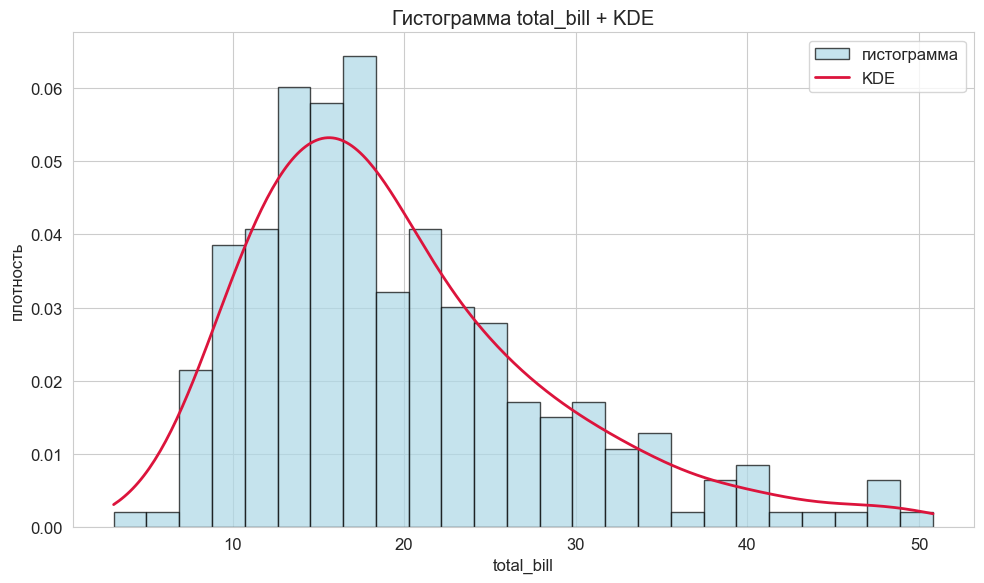

In [4]:
fig, ax = plt.subplots()
ax.hist(tips["total_bill"], bins=25, density=True, color="lightblue",
        edgecolor="black", alpha=0.7, label="гистограмма")

# KDE по данным
kde = stats.gaussian_kde(tips["total_bill"].dropna())
xs = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 300)
ax.plot(xs, kde(xs), color="crimson", lw=2, label="KDE")

ax.set_xlabel("total_bill")
ax.set_ylabel("плотность")
ax.set_title("Гистограмма total_bill + KDE")
ax.legend()
plt.tight_layout()
plt.show()


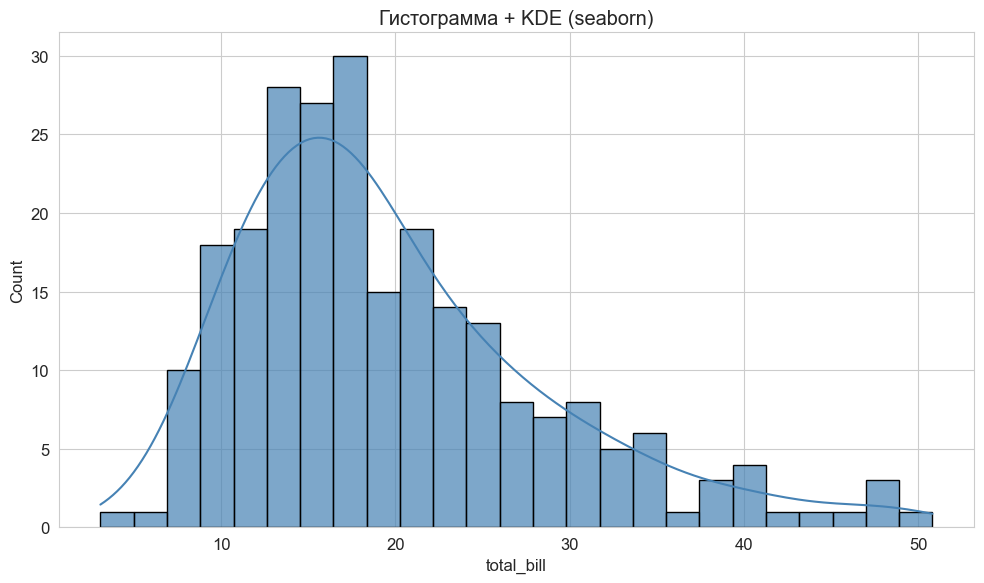

In [5]:
# То же через seaborn
plt.figure()
sns.histplot(tips["total_bill"], bins=25, kde=True, color="steelblue",
             edgecolor="black", alpha=0.7)
plt.xlabel("total_bill")
plt.title("Гистограмма + KDE (seaborn)")
plt.tight_layout()
plt.show()


---
## 2. Среднее и стандартная ошибка среднего (SE)

$$
\mathrm{SE} = \frac{s}{\sqrt{n}},
$$
где $s$ — выборочное стандартное отклонение, $n$ — объём выборки.


In [10]:
x = tips["total_bill"]
n = x.count()
mean_x = x.mean()
sd_x = x.std(ddof=1)
se_x = sd_x / np.sqrt(n)

print(f"n     = {n}")
print(f"mean  = {mean_x:.4f}")
print(f"sd    = {sd_x:.4f}")
print(f"SE    = {se_x:.4f}")


n     = 244
mean  = 19.7859
sd    = 8.9024
SE    = 0.5699


---
## 3. Медиана, квантили, summary

`describe` / `quantile` дают «сжатый» портрет распределения.


In [11]:
print("Медиана:", x.median())
print("Квантили 0%, 25%, 50%, 75%, 100%:")
print(x.quantile([0, 0.25, 0.5, 0.75, 1.0]))
print()
print(x.describe())


Медиана: 17.795
Квантили 0%, 25%, 50%, 75%, 100%:
0.00     3.0700
0.25    13.3475
0.50    17.7950
0.75    24.1275
1.00    50.8100
Name: total_bill, dtype: float64

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


---
## 4. Асимметрия (skewness) и эксцесс (kurtosis)

- **Skewness** > 0 — правый хвост длиннее (типично для сумм платежей).
- **Kurtosis** (excess) > 0 — хвосты тяжелее, чем у нормального.

В SciPy: `stats.skew`, `stats.kurtosis` (по умолчанию *excess* kurtosis).


In [12]:
sk = stats.skew(x, bias=False)
ku = stats.kurtosis(x, bias=False)
print(f"skewness = {sk:.4f}")
print(f"kurtosis (excess) = {ku:.4f}")


skewness = 1.1332
kurtosis (excess) = 1.2185


---
## 5. Описательные статистики **по группам**

`groupby` + агрегирующая функция — аналог сводных таблиц по фактору.


In [13]:
# Сводка total_bill по полу клиента
print(tips.groupby("sex")["total_bill"].describe().round(2))


        count   mean   std   min    25%    50%    75%    max
sex                                                         
Male    157.0  20.74  9.25  7.25  14.00  18.35  24.71  50.81
Female   87.0  18.06  8.01  3.07  12.75  16.40  21.52  44.30


C:\Users\kirya\AppData\Local\Temp\ipykernel_24728\553101697.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby("sex")["total_bill"].describe().round(2))


In [8]:
# Несколько статистик сразу
tips.groupby("day")["tip"].agg(["count", "mean", "median", "std"]).round(3)


C:\Users\kirya\AppData\Local\Temp\ipykernel_24728\2339683703.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby("day")["tip"].agg(["count", "mean", "median", "std"]).round(3)


,count,mean,median,std
day,,,,
Thur,62,2.771,2.305,1.240
Fri,19,2.735,3.000,1.020
Sat,87,2.993,2.750,1.631
Sun,76,3.255,3.150,1.235


---
## 6. Boxplot по категориям

«Ящик с усами» показывает медиану, квартили и выбросы по группам.


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x="day", y="total_bill", hue="sex")
plt.title("total_bill по дням недели и полу")
plt.tight_layout()
plt.show()


---
## 7. Медианы в разрезе двух факторов

Сводная таблица медиан, затем столбчатая диаграмма.


In [ ]:
med_two = tips.groupby(["day", "sex"])["tip"].median().unstack()
print(med_two.round(2))

med_two.plot(kind="bar", figsize=(9, 5), edgecolor="black")
plt.ylabel("Медиана tip")
plt.xlabel("День")
plt.title("Медианные чаевые: день × пол")
plt.xticks(rotation=0)
plt.legend(title="sex")
plt.tight_layout()
plt.show()


---
## 8. Barplot для одной группировки

Сначала считаем агрегат, потом рисуем столбцы.


In [ ]:
med_by_time = tips.groupby("time")["total_bill"].median().sort_values(ascending=False)
print(med_by_time)

plt.figure(figsize=(6, 4))
med_by_time.plot(kind="bar", color="teal", edgecolor="black")
plt.ylabel("Медиана total_bill")
plt.title("Медианный счёт: обед vs ужин")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## 9. Ещё один пример группировки: размер компании

Медиана чаевых по числу гостей (`size`) — вся выборка и отдельно по времени дня.


In [14]:
# Вся выборка
med_size = tips.groupby("size")["tip"].median()
print("Медиана tip по size:")
print(med_size)

# По времени дня
med_size_time = tips.groupby(["time", "size"])["tip"].median().unstack()
print("\nМедиана tip: time × size")
print(med_size_time.round(2))


Медиана tip по size:
size
1    1.415
2    2.500
3    3.290
4    3.760
5    5.000
6    5.000
Name: tip, dtype: float64

Медиана tip: time × size
size       1     2     3     4    5    6
time                                    
Lunch   1.88  2.00  3.00  4.00  5.0  5.0
Dinner  1.00  2.58  3.41  3.72  4.0  5.0


C:\Users\kirya\AppData\Local\Temp\ipykernel_24728\2207455978.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_size_time = tips.groupby(["time", "size"])["tip"].median().unstack()


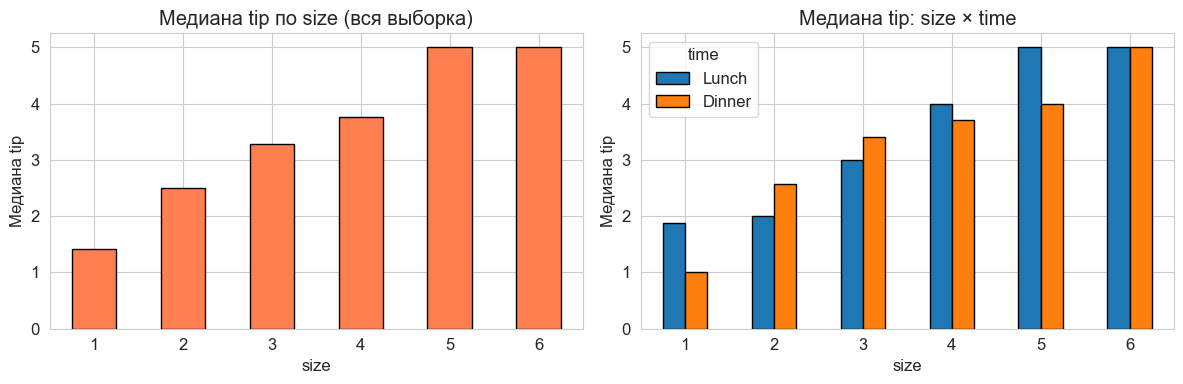

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

med_size.plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Медиана tip по size (вся выборка)")
axes[0].set_ylabel("Медиана tip")
axes[0].set_xlabel("size")

med_size_time.T.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Медиана tip: size × time")
axes[1].set_ylabel("Медиана tip")
axes[1].set_xlabel("size")
axes[1].legend(title="time")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


---
## Шпаргалка по методам (Python)

| Задача | Код |
|--------|-----|
| Загрузка CSV | `pd.read_csv(path_or_url)` |
| Среднее / sd | `s.mean()`, `s.std(ddof=1)` |
| SE среднего | `s.std(ddof=1) / np.sqrt(s.count())` |
| Медиана, квантили | `s.median()`, `s.quantile([0.25, 0.5, 0.75])` |
| Summary | `s.describe()` / `df.describe()` |
| Skewness / kurtosis | `stats.skew(x)`, `stats.kurtosis(x)` |
| По группам | `df.groupby("A")["y"].mean()` / `.median()` / `.describe()` |
| Два фактора | `df.groupby(["A", "B"])["y"].median().unstack()` |
| Гистограмма + KDE | `plt.hist(..., density=True)` + KDE / `sns.histplot(..., kde=True)` |
| Boxplot | `sns.boxplot(data=df, x="A", y="y")` |
| Barplot | `series.plot(kind="bar")` |

---
## Что сделать после лекции

1. Откройте лабораторное задание и выполните его **самостоятельно** на указанном там наборе данных.
2. Обращайте внимание на тип переменной: числовая vs категориальная — от этого зависит выбор графика и агрегата.

Удачи с описательными статистиками!


In [ ]:
import os
from google.colab import files

print("Доступные файлы в рабочей директории:")
print(os.listdir())

uploaded = files.upload()
file_name = next(iter(uploaded))

if file_name.endswith('.csv'):
    data = pd.read_csv(file_name)
elif file_name.endswith('.xlsx'):
    data = pd.read_excel(file_name)
else:
    raise ValueError("Формат файла не поддерживается. Используйте CSV или Excel.")

print(f"\nФайл '{file_name}' успешно загружен!")
data.to_excel('data.xlsx')